<a href="https://colab.research.google.com/github/emilsar/Cedars/blob/main/Project3/5_DL_image_segmentation_e.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import libraries

In [6]:
!pip install segmentation_models_pytorch
!git clone https://github.com/emilsar/Cedars.git
%cd Cedars/Project3

fatal: destination path 'Cedars' already exists and is not an empty directory.
/content/Cedars/Project3


In [4]:
#from semseg_functions import load_imgs_labels,train_model,make_predictions,load_model,run_and_visualize_layer_activation,show_filters
from matplotlib import pyplot as plt
import numpy as np
from scipy.stats import spearmanr
import pandas as pd
import torch, cv2, glob, tqdm, os, copy
from sklearn.model_selection import train_test_split
from scipy import ndimage
from skimage import measure, color, io
from skimage.io import imread
import segmentation_models_pytorch as smp
from PIL import Image
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn


# Load Data

In [37]:
# Load images and labels directly
X = np.stack([np.load(f"imagedata/X/{i}.npy") for i in range(len(glob.glob("imagedata/X/*.npy")))], axis=0)
y = np.stack([np.load(f"imagedata/y/{i}.npy") for i in range(len(glob.glob("imagedata/y/*.npy")))], axis=0)

# Process
images = np.transpose(X.numpy()*255, (0,2,3,1)).astype(np.uint8)
labels = y

# Filter out images with no nucleus
no_nucleus = (labels==2).sum(axis=(1,2)) == 0
images = images[~no_nucleus]
labels = labels[~no_nucleus]

X_train,X_test,Y_train,Y_test=train_test_split(images,labels,test_size=0.2,stratify=labels.mean((1,2))>=np.median(labels.mean((1,2))),random_state=42)
X_train,X_val,Y_train,Y_val=train_test_split(X_train,Y_train,test_size=0.2,stratify=Y_train.mean((1,2))>=np.median(Y_train.mean((1,2))),random_state=42)
X_train,X_val,X_test,Y_train,Y_val,Y_test=torch.FloatTensor(X_train).permute((0,3,1,2)),torch.FloatTensor(X_val).permute((0,3,1,2)),torch.FloatTensor(X_test).permute((0,3,1,2)),torch.LongTensor(Y_train),torch.LongTensor(Y_val),torch.LongTensor(Y_test)


AttributeError: 'numpy.ndarray' object has no attribute 'numpy'

In [36]:
%ls
print(glob.glob("*.py"))

 0_package_installs.ipynb               final_thresholds.pkl
 1_load_data_operations.ipynb           imagedata/
 1_prepdata.py                          Pipeline.ipynb
 2_Intensity_Approach.ipynb             Pre_1_load_data_operations.ipynb
 3_Feature_Extraction.ipynb             Pre_2_Intensity_Approach.ipynb
 4_KMeans_RF.ipynb                      Project3_Description.md
 5_DL_image_segmentation_e.ipynb        __pycache__/
 5_DL_image_segmentation.ipynb          QuPath_Examples/
 artificial_cell.npy                    QuPath_Examples.zip
 Bayesian_Optimization_Tutorial.ipynb  'SAM protocol.docx'
 cell_images/                           seg_models/
 deprecated/                            semseg_functions.py
 DL_result_imgs/                        specimens_toy_data.pkl
 feature_extraction_utils.py            Tensors_and_Images.ipynb
['1_prepdata.py', 'semseg_functions.py', 'feature_extraction_utils.py']


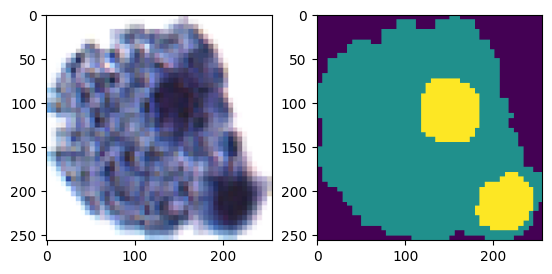

In [9]:
plt.subplot(1,2,1)
plt.imshow(images[7])
plt.subplot(1,2,2)
plt.imshow(labels[7])

# Semseg Functions

In [10]:
def show_filters(weights, n_cols=8, cmap='gray'):
    """
    Display convolutional filters as images.

    Args:
        weights (torch.Tensor): Conv layer weights of shape [out_channels, in_channels, H, W]
        n_cols (int): Number of columns in the display grid.
        cmap (str): Color map to use ('gray', 'viridis', etc.)
    """
    # Detach and move to CPU
    weights = weights.detach().cpu()

    # If multi-channel (e.g., 3 input channels), reduce to grayscale by averaging
    if weights.shape[1] == 3:
        weights = weights.mean(dim=1, keepdim=True)

    # Normalize each filter for better contrast
    weights = (weights - weights.min(dim=-1, keepdim=True)[0].min(dim=-2, keepdim=True)[0])
    weights = weights / weights.max(dim=-1, keepdim=True)[0].max(dim=-2, keepdim=True)[0]

    n_filters = weights.shape[0]
    n_rows = int(np.ceil(n_filters / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols, n_rows))
    axes = axes.flatten()

    for i in range(n_filters):
        filter_img = weights[i, 0]  # first input channel (or averaged)
        axes[i].imshow(filter_img, cmap=cmap)
        axes[i].axis('off')

    # Turn off remaining axes
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()


# --- Utility to Register Hook ---
def capture_activation(model, layer_name, activations_dict):
    """
    Register a forward hook to capture activations from a given layer.
    """
    def hook_fn(module, input, output):
        activations_dict[layer_name] = output.detach().cpu()
    layer = dict([*model.named_modules()])[layer_name]
    return layer.register_forward_hook(hook_fn)

# --- Visualization Function ---
def plot_input_activation_output(input_img, activations, output_img, act_layer_name, n_cols=8):
    """
    Plot input image, activations, and model output side by side.
    """

    # Activations
    act = activations[act_layer_name].squeeze(0)  # shape: [C, H, W]
    n_features = act.shape[0]
    n_rows = int(np.ceil(n_features / n_cols))
    fig_act, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols, n_rows))
    axes = axes.flatten()
    for i in range(min(n_features, len(axes))):
        axes[i].imshow(act[i], cmap='viridis')
        axes[i].axis('off')
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    plt.suptitle(f"Activations from {act_layer_name}", fontsize=14)

    plt.tight_layout()
    plt.show()

def get_layer_activations(model, layer_name, input_tensor):
    """
    Runs a forward pass and captures activations from a specified layer.

    Args:
        model (torch.nn.Module): The model to inspect.
        layer_name (str): Name of the layer to hook (e.g., 'encoder.conv1').
        input_tensor (torch.Tensor): Input image tensor of shape [1, C, H, W].

    Returns:
        output (torch.Tensor): Model output.
        activations (dict): Dictionary with one key (layer_name) -> activations tensor.
    """
    activations = {}

    def hook_fn(module, input, output):
        activations[layer_name] = output.detach().cpu()

    layer = dict([*model.named_modules()])[layer_name]
    hook = layer.register_forward_hook(hook_fn)

    model.eval()
    with torch.no_grad():
        output = model(input_tensor)

    hook.remove()
    return output, activations

def run_and_visualize_layer_activation(model, layer_name, input_tensor, n_cols=8, cmap='viridis'):
    """
    Runs a forward pass, captures activations from a specified layer, and visualizes
    input, activations, and output.

    Args:
        model (torch.nn.Module): The model to inspect.
        layer_name (str): Name of the layer to hook (e.g., 'encoder.conv1').
        input_tensor (torch.Tensor): Input tensor of shape [1, C, H, W].
        n_cols (int): Columns in activation grid.
        cmap (str): Color map for activations.
    """
    activations = {}

    def hook_fn(module, input, output):
        activations[layer_name] = output.detach().cpu()

    layer = dict([*model.named_modules()])[layer_name]
    hook = layer.register_forward_hook(hook_fn)

    model.eval()
    with torch.no_grad():
        output = model(input_tensor)

    hook.remove()

    # Visualize everything
    plot_input_activation_output(input_tensor.cpu(), activations, output, layer_name, n_cols=n_cols)

def load_imgs_labels(train_dir="./train",val_dir="./val"):
    train_imgs=np.stack(list(map(imread,sorted(glob.glob(os.path.join(train_dir,"imgs","*.png"))))))
    X_train=torch.FloatTensor(train_imgs).permute((0,3,1,2))/255

    val_imgs=np.stack(list(map(imread,sorted(glob.glob(os.path.join(val_dir,"imgs","*.png"))))))
    X_val=torch.FloatTensor(val_imgs).permute((0,3,1,2))/255

    train_lbls=np.stack(list(map(lambda x: imread(x)[...,0].astype(int),sorted(glob.glob(os.path.join(train_dir,"labels","*.png"))))))
    Y_train=torch.LongTensor(train_lbls)

    val_lbls=np.stack(list(map(lambda x: imread(x)[...,0].astype(int),sorted(glob.glob(os.path.join(val_dir,"labels","*.png"))))))
    Y_val=torch.LongTensor(val_lbls)

    return X_train,Y_train,X_val,Y_val

def load_model(path_dir = None, model_key="unet", encoder_name="resnet18", device="cpu"):
    model=dict(unet=smp.Unet,
                fpn=smp.FPN).get(model_key, smp.Unet)
    model=model(classes=3,in_channels=3, encoder_name=encoder_name, encoder_weights=None)
    if path_dir is not None:
        model_fnames=glob.glob(path_dir + '/*_model.pkl')
        if len(model_fnames)>0:
            model_list=sorted(model_fnames, key=os.path.getmtime)
            model.load_state_dict(torch.load(model_list[-1], map_location="cpu"))
    return model

def train_model(X_train,Y_train,X_val,Y_val,save=True,n_epochs=10, model_key="unet", encoder_name="resnet18", path_dir = "./seg_models", device="cpu"):
    train_data=TensorDataset(X_train,Y_train)
    val_data=TensorDataset(X_val,Y_val)

    train_dataloader=DataLoader(train_data,batch_size=8,shuffle=True)
    train_dataloader_ordered=DataLoader(train_data,batch_size=8,shuffle=False)
    val_dataloader=DataLoader(val_data,batch_size=8,shuffle=False)
    encoder_name="resnet18" if encoder_name not in smp.encoders.get_encoder_names() else encoder_name
    model=load_model(None, model_key, encoder_name, device)
    optimizer=torch.optim.Adam(model.parameters())
    class_weight=compute_class_weight(class_weight='balanced', classes=np.unique(Y_train.numpy().flatten()), y=Y_train.numpy().flatten())
    class_weight=torch.FloatTensor(class_weight).to(device)

    loss_fn=torch.nn.CrossEntropyLoss(weight=class_weight)
    if not os.path.exists(path_dir): os.makedirs(path_dir,exist_ok=True)
    min_loss=np.inf
    for epoch in range(1,n_epochs+1):
        # training set
        model.train(True)
        for i,(x,y_true) in enumerate(train_dataloader):
            if torch.cuda.is_available():
                x=x.to(device)
                y_true=y_true.to(device)
            optimizer.zero_grad()

            y_pred=model(x)
            loss=loss_fn(y_pred,y_true)

            loss.backward()
            optimizer.step()

            print(f"Training: Epoch {epoch}, Batch {i}, Loss: {round(loss.item(),3)}")

        # validation set
        model.train(False)
        with torch.no_grad():
            val_loss = []
            for i,(x,y_true) in enumerate(val_dataloader):
                if torch.cuda.is_available():
                    x=x.to(device)
                    y_true=y_true.to(device)
                y_pred=model(x)
                loss=loss_fn(y_pred,y_true)
                val_loss.append(loss.item())

            val_loss=np.mean(val_loss)
            print(f"Val: Epoch {epoch}, Loss: {round(val_loss,3)}")
            if val_loss < min_loss:
                min_loss=val_loss
                best_model=copy.deepcopy(model.state_dict())
                if save:
                    with open(path_dir + f'/{epoch}.{i}_model.pkl', "w") as f:
                        torch.save(model.state_dict(), path_dir + f'/{epoch}.{i}_model.pkl')

    model.load_state_dict(best_model)
    return model

def make_predictions(X_val,model=None,save=True,path_dir = "./seg_models", model_key="unet", encoder_name="resnet18", device="cpu"):
    val_data=TensorDataset(X_val)
    val_dataloader=DataLoader(val_data,batch_size=8,shuffle=False)
    predictions=[]
    encoder_name="resnet18" if encoder_name not in smp.encoders.get_encoder_names() else encoder_name
    # load most recent saved model
    if model is None and save:
        model=load_model(path_dir, model_key, encoder_name, device)
    model=model.to(device)
    model.train(False)
    with torch.no_grad():
        for i,(x,) in enumerate(val_dataloader):
            if torch.cuda.is_available():
                x=x.to(device)
            y_pred=torch.softmax(model(x),1).detach().cpu().numpy()
            predictions.append(y_pred)
    predictions=np.concatenate(predictions,axis=0)
    return predictions

# Train model

In [11]:
model=train_model(X_train,Y_train,X_val,Y_val, encoder_name="resnet34", model_key="FPN", n_epochs=3)

Training: Epoch 1, Batch 0, Loss: 1.262
Training: Epoch 1, Batch 1, Loss: 0.85
Training: Epoch 1, Batch 2, Loss: 0.754
Training: Epoch 1, Batch 3, Loss: 0.622
Training: Epoch 1, Batch 4, Loss: 0.632
Training: Epoch 1, Batch 5, Loss: 0.567
Training: Epoch 1, Batch 6, Loss: 0.498
Training: Epoch 1, Batch 7, Loss: 0.56
Training: Epoch 1, Batch 8, Loss: 0.502
Training: Epoch 1, Batch 9, Loss: 0.662
Training: Epoch 1, Batch 10, Loss: 0.419
Training: Epoch 1, Batch 11, Loss: 0.522
Training: Epoch 1, Batch 12, Loss: 0.59
Training: Epoch 1, Batch 13, Loss: 0.534
Training: Epoch 1, Batch 14, Loss: 0.455
Training: Epoch 1, Batch 15, Loss: 0.553
Val: Epoch 1, Loss: 161.907
Training: Epoch 2, Batch 0, Loss: 0.456
Training: Epoch 2, Batch 1, Loss: 0.398
Training: Epoch 2, Batch 2, Loss: 0.446
Training: Epoch 2, Batch 3, Loss: 0.321
Training: Epoch 2, Batch 4, Loss: 0.353
Training: Epoch 2, Batch 5, Loss: 0.359
Training: Epoch 2, Batch 6, Loss: 0.374
Training: Epoch 2, Batch 7, Loss: 0.384
Training:

# Predict on held out test

In [12]:
y_val_pred=make_predictions(X_val, encoder_name="resnet34", model_key="FPN")#,model=model)#model=None)
y_test_pred=make_predictions(X_test, encoder_name="resnet34", model_key="FPN")#,model=model)#model=None)

In [13]:
y_val_pred_lbls=y_val_pred.argmax(1)
y_test_pred_lbls=y_test_pred.argmax(1)

# Report segmentation model performance

In [14]:
from sklearn.metrics import classification_report

In [15]:
print(classification_report(Y_val.numpy().flatten(),y_val_pred_lbls.flatten()))

              precision    recall  f1-score   support

           0       0.71      1.00      0.83    735746
           1       0.97      0.42      0.59    888107
           2       0.65      0.97      0.78    407763

    accuracy                           0.74   2031616
   macro avg       0.78      0.80      0.73   2031616
weighted avg       0.81      0.74      0.71   2031616



In [16]:
print(classification_report(Y_test.numpy().flatten(),y_test_pred_lbls.flatten()))

              precision    recall  f1-score   support

           0       0.74      1.00      0.85    906849
           1       0.92      0.41      0.56   1087940
           2       0.62      0.93      0.74    561115

    accuracy                           0.73   2555904
   macro avg       0.76      0.78      0.72   2555904
weighted avg       0.79      0.73      0.70   2555904



# Compare true and predicted NC ratios

In [17]:
nucleus_val_pred=(y_val_pred_lbls.reshape(y_val_pred_lbls.shape[0],-1)==2).sum(axis=1)
cytoplasm_val_pred=(y_val_pred_lbls.reshape(y_val_pred_lbls.shape[0],-1)==1).sum(axis=1)
nc_ratio_val_pred=nucleus_val_pred/(nucleus_val_pred+cytoplasm_val_pred)

nucleus_test_pred=(y_test_pred_lbls.reshape(y_test_pred_lbls.shape[0],-1)==2).sum(axis=1)
cytoplasm_test_pred=(y_test_pred_lbls.reshape(y_test_pred_lbls.shape[0],-1)==1).sum(axis=1)
nc_ratio_test_pred=nucleus_test_pred/(nucleus_test_pred+cytoplasm_test_pred)

In [18]:
nucleus_val_true=(Y_val.reshape(Y_val.shape[0],-1)==2).sum(axis=1)
cytoplasm_val_true=(Y_val.reshape(Y_val.shape[0],-1)==1).sum(axis=1)
nc_ratio_val_true=(nucleus_val_true/(nucleus_val_true+cytoplasm_val_true)).numpy()

nucleus_test_true=(Y_test.reshape(Y_test.shape[0],-1)==2).sum(axis=1)
cytoplasm_test_true=(Y_test.reshape(Y_test.shape[0],-1)==1).sum(axis=1)
nc_ratio_test_true=(nucleus_test_true/(nucleus_test_true+cytoplasm_test_true)).numpy()

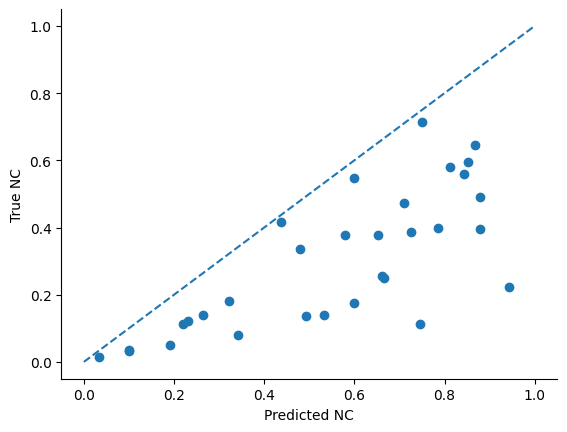

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.scatter(nc_ratio_val_pred,nc_ratio_val_true)
plt.plot([0,1],[0,1],ls="--")
plt.xlabel("Predicted NC")
plt.ylabel("True NC")
sns.despine()

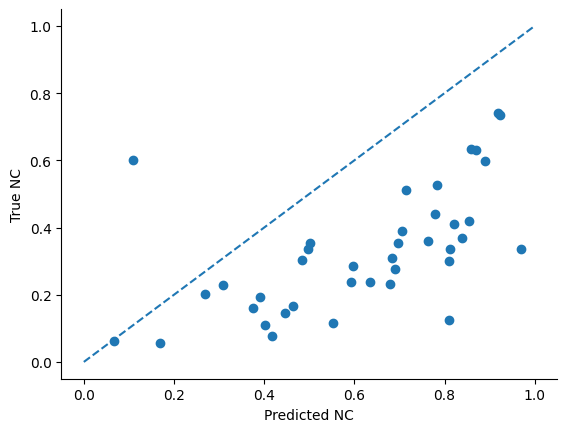

In [21]:
plt.scatter(nc_ratio_test_pred,nc_ratio_test_true)
plt.plot([0,1],[0,1],ls="--")
plt.xlabel("Predicted NC")
plt.ylabel("True NC")
sns.despine()

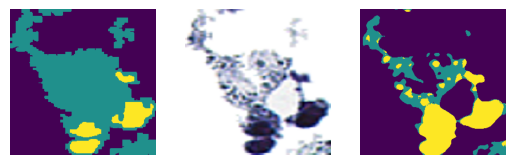

In [22]:
# ! mkdir DL_result_imgs
for idx in range(len(X_val)):
    plt.subplot(131)
    plt.imshow(Y_val[idx])
    plt.axis("off")
    plt.subplot(132)
    plt.imshow((X_val[idx]).permute((1,2,0)).numpy().astype(int))
    plt.axis("off")
    plt.subplot(133)
    plt.imshow(y_val_pred_lbls[idx])
    plt.axis("off")
    plt.savefig(f"DL_result_imgs/urothelial_cell_{idx}.png")

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

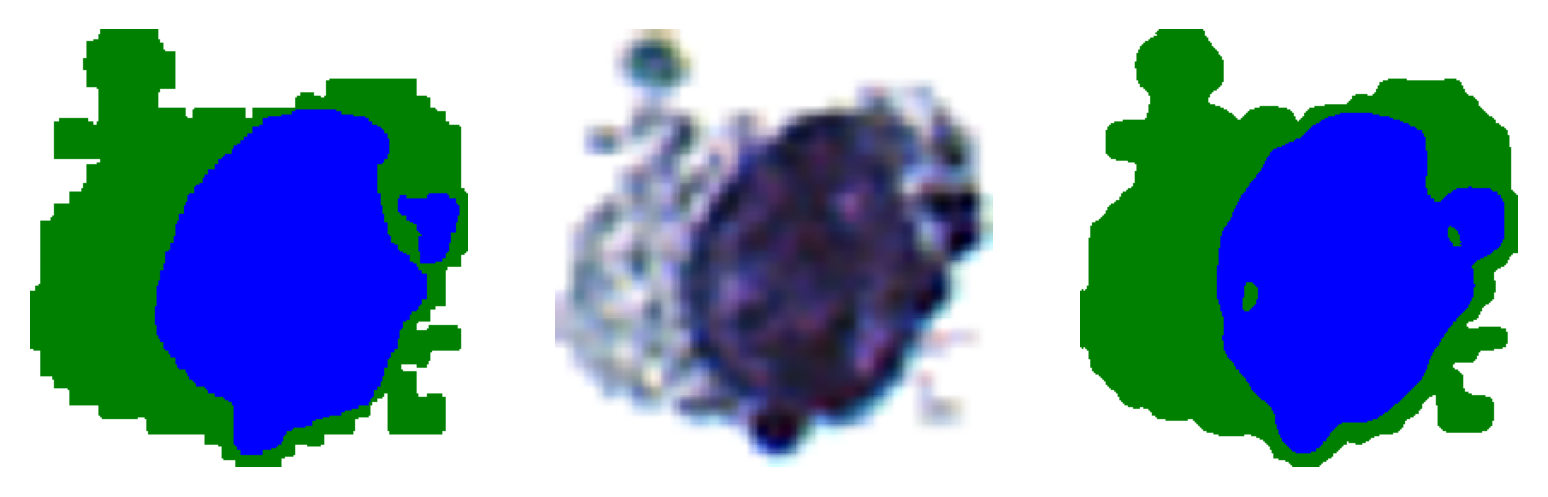

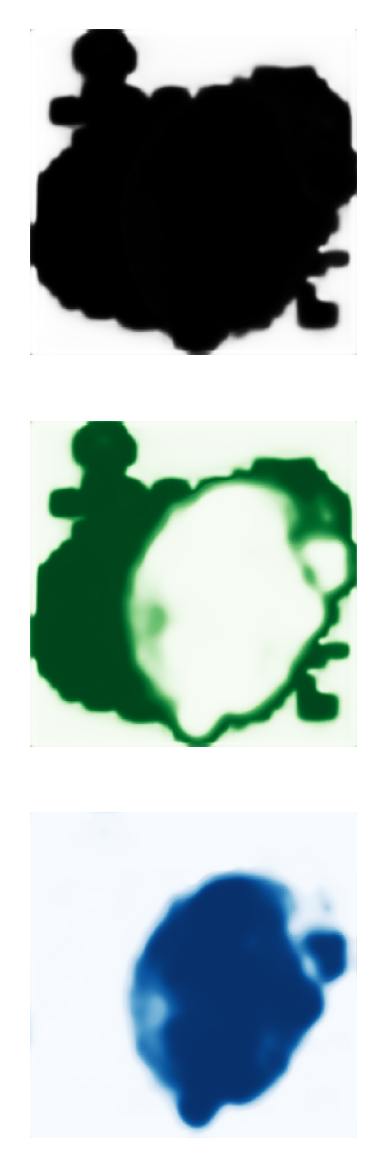

In [ ]:
import matplotlib; matplotlib.rcParams['figure.dpi']=300
import matplotlib.pyplot as plt

idx=22
plt.figure()
plt.subplot(131)
plt.imshow(Y_val[idx], cmap=plt.matplotlib.colors.ListedColormap(['white', 'green', 'blue']))
plt.axis("off")
plt.subplot(132)
plt.imshow((X_val[idx]).permute((1,2,0)).numpy().astype(int))
plt.axis("off")
plt.subplot(133)
plt.imshow(y_val_pred_lbls[idx], cmap=plt.matplotlib.colors.ListedColormap(['white', 'green', 'blue']))
plt.axis("off")
plt.figure()
plt.subplot(311)
plt.imshow(y_val_pred[idx][0], cmap="Greys_r")
plt.axis("off")
plt.subplot(312)
plt.imshow(y_val_pred[idx][1], cmap="Greens")
plt.axis("off")
plt.subplot(313)
plt.imshow(y_val_pred[idx][2], cmap="Blues")
plt.axis("off")

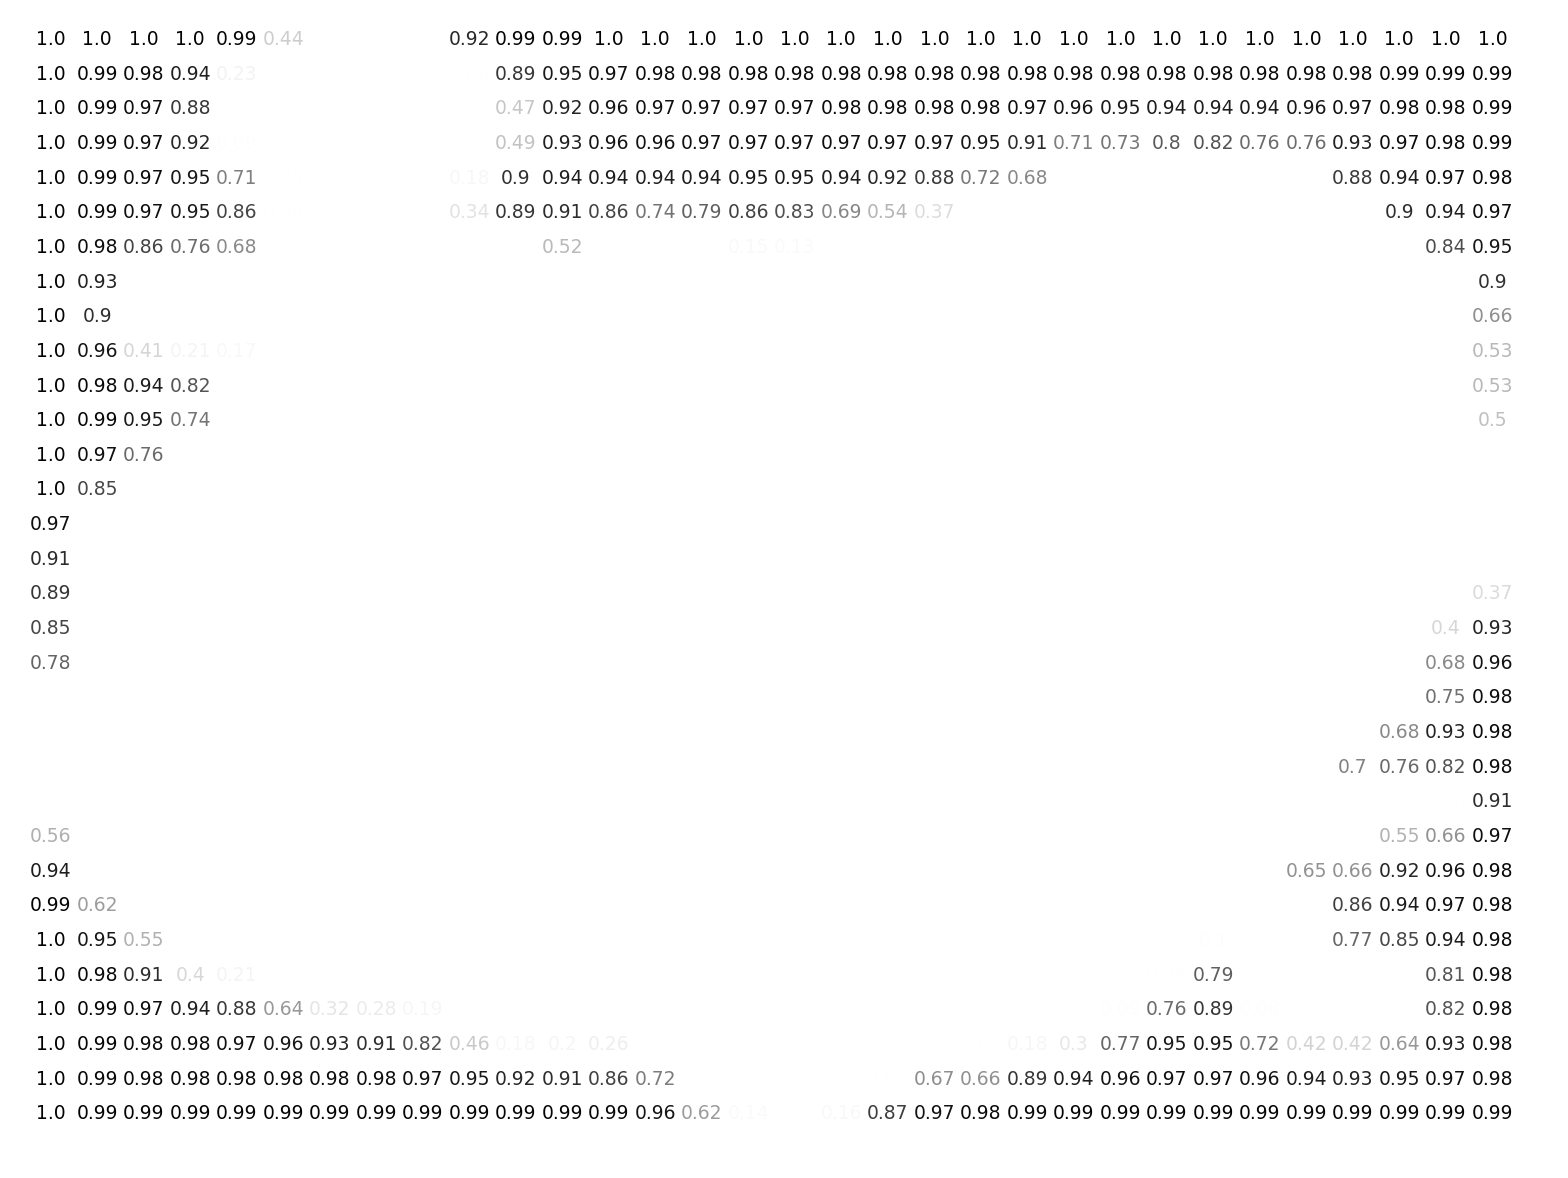

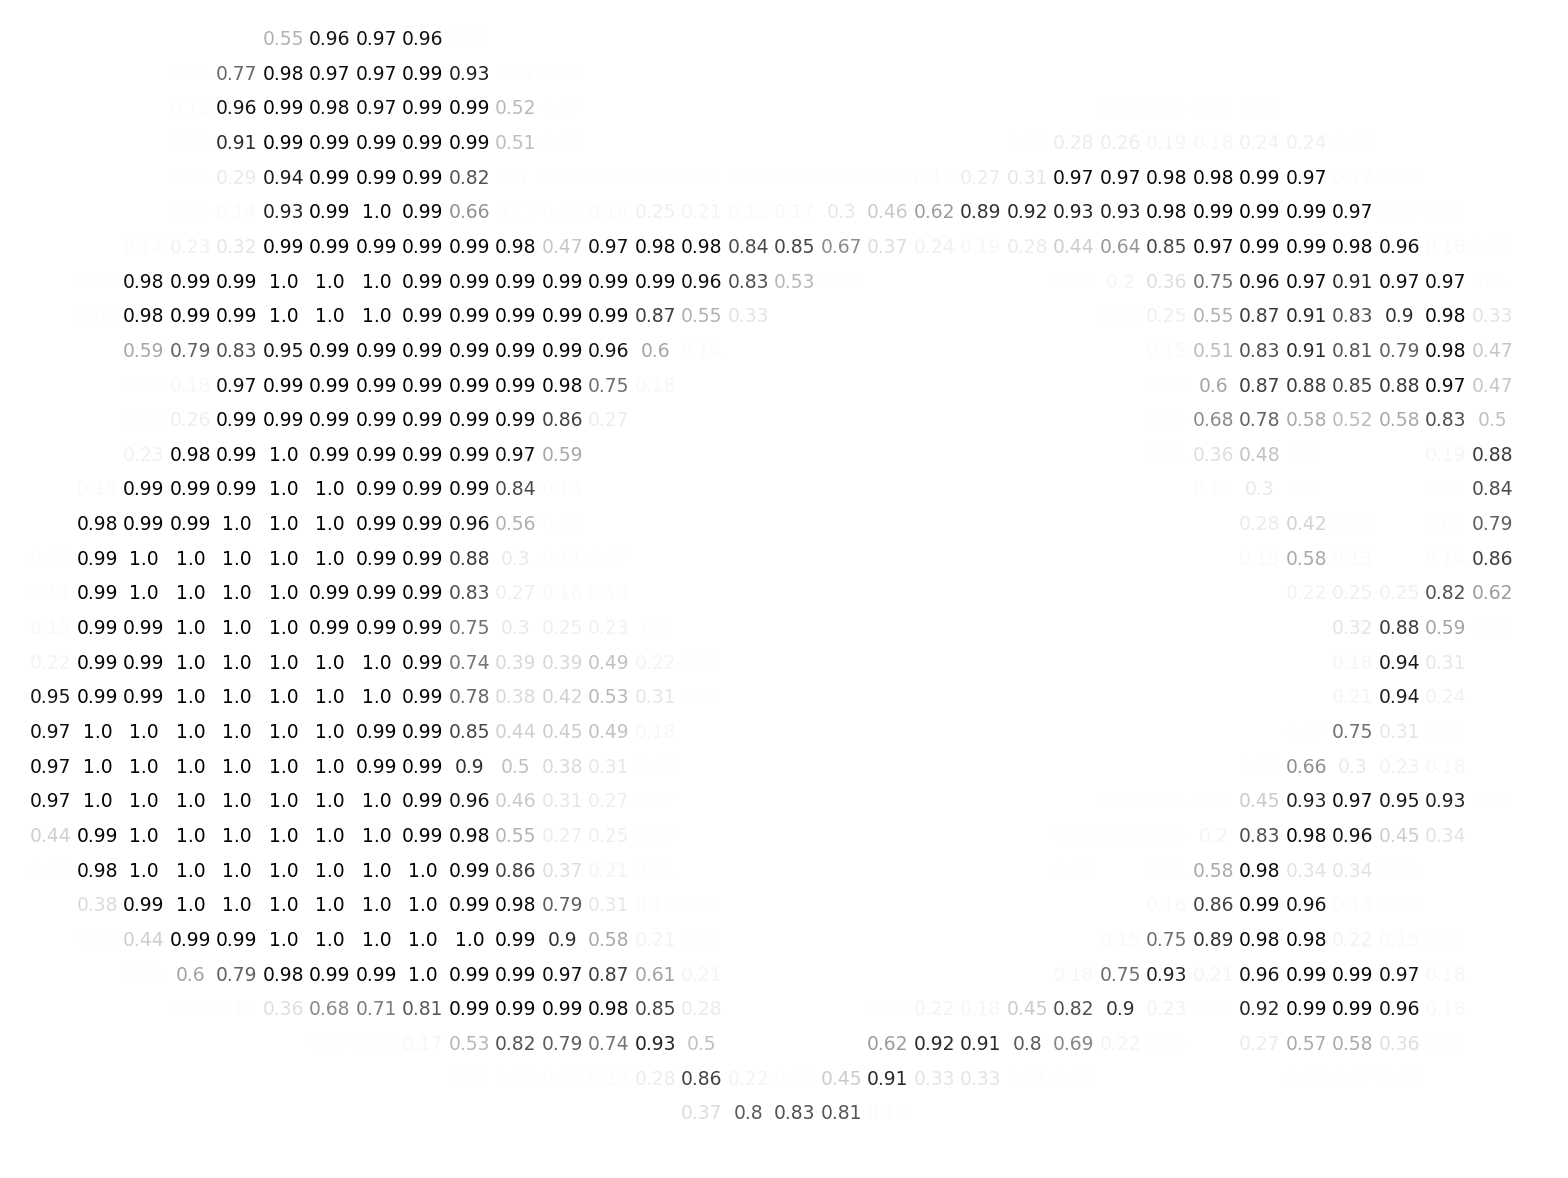

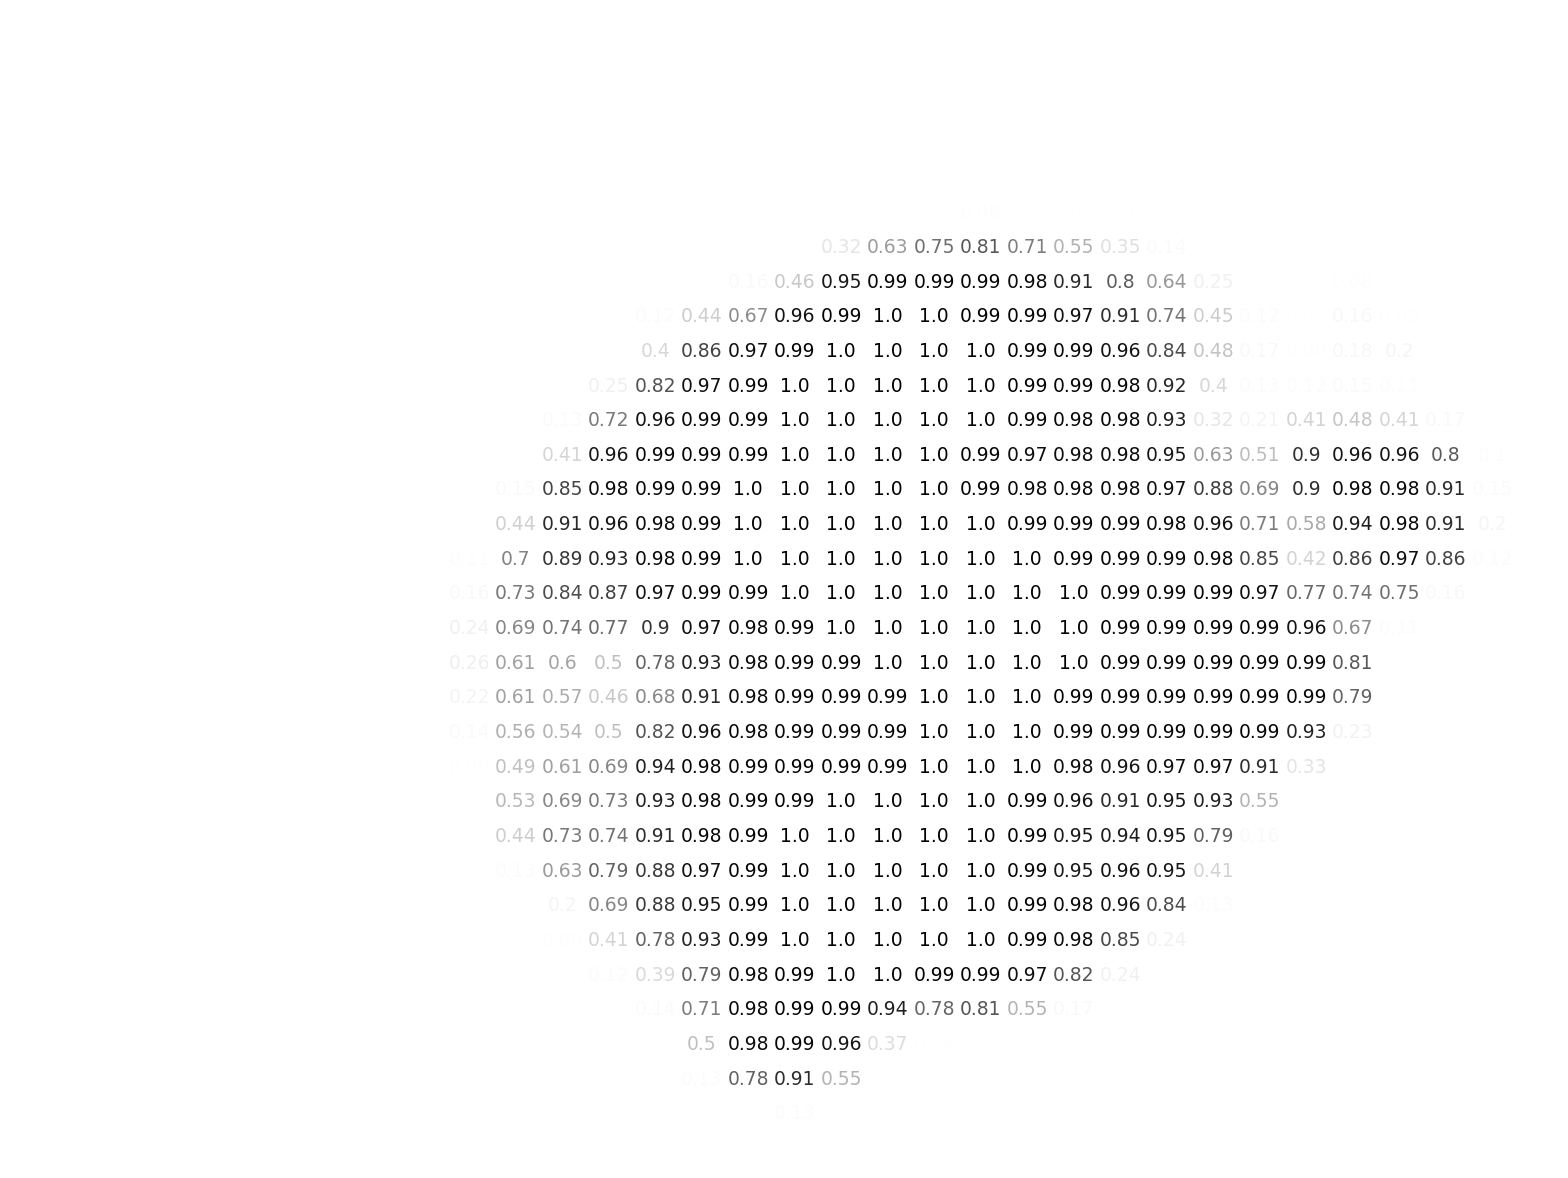

In [ ]:

for class_idx in range(y_val_pred[idx].shape[0]):
    img_gray_small=cv2.resize(y_val_pred[idx][class_idx],None,fx=1/8,fy=1/8)
    plt.figure()
    for i in range(img_gray_small.shape[0]):
        for j in range(img_gray_small.shape[1]):
            text = plt.text(j/img_gray_small.shape[0], i/img_gray_small.shape[1], str(round(img_gray_small[i, j],2)),
                        ha="center", va="center", color="k", alpha=(img_gray_small[i, j])**2, fontsize=4.5)#**2/2
    plt.axis("off")
    plt.gca().invert_yaxis()

In [23]:
# correlation - true vs predicted
spearmanr(nc_ratio_val_pred,nc_ratio_val_true)

SignificanceResult(statistic=np.float64(0.765725806451613), pvalue=np.float64(5.186912350884595e-07))

In [24]:
# error - true vs predicted
np.abs(nc_ratio_val_pred-nc_ratio_val_true).mean()

np.float64(0.2560913849719261)

In [25]:
print(spearmanr(nc_ratio_test_pred,nc_ratio_test_true))
print(np.abs(nc_ratio_test_pred-nc_ratio_test_true).mean())

SignificanceResult(statistic=np.float64(0.7056680161943321), pvalue=np.float64(5.238834440350619e-07))
0.31348653497360124


(480, 640, 4)
(480, 640, 4)
(480, 640, 4)


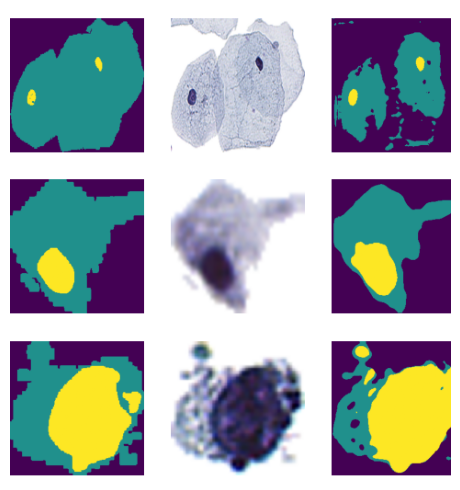

In [26]:
import matplotlib.pyplot as plt

result_images = [
    "DL_result_imgs/urothelial_cell_11.png",
    "DL_result_imgs/urothelial_cell_21.png",
    "DL_result_imgs/urothelial_cell_22.png"
]

# Create a single figure with subplots
fig, axes = plt.subplots(3, 1, figsize=(15, 5))

# Plot each image in a subplot
for ax, img_path in zip(axes, result_images):
    im_=plt.imread(img_path)
    print(im_.shape)
    ax.imshow(im_[160:im_.shape[0]-160,80:im_.shape[1]-80])
    ax.axis('off')

plt.tight_layout()
plt.show()


## Bonus: Plot the neural network filters.

In [27]:
model=load_model(encoder_name="resnet34", model_key="FPN")


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

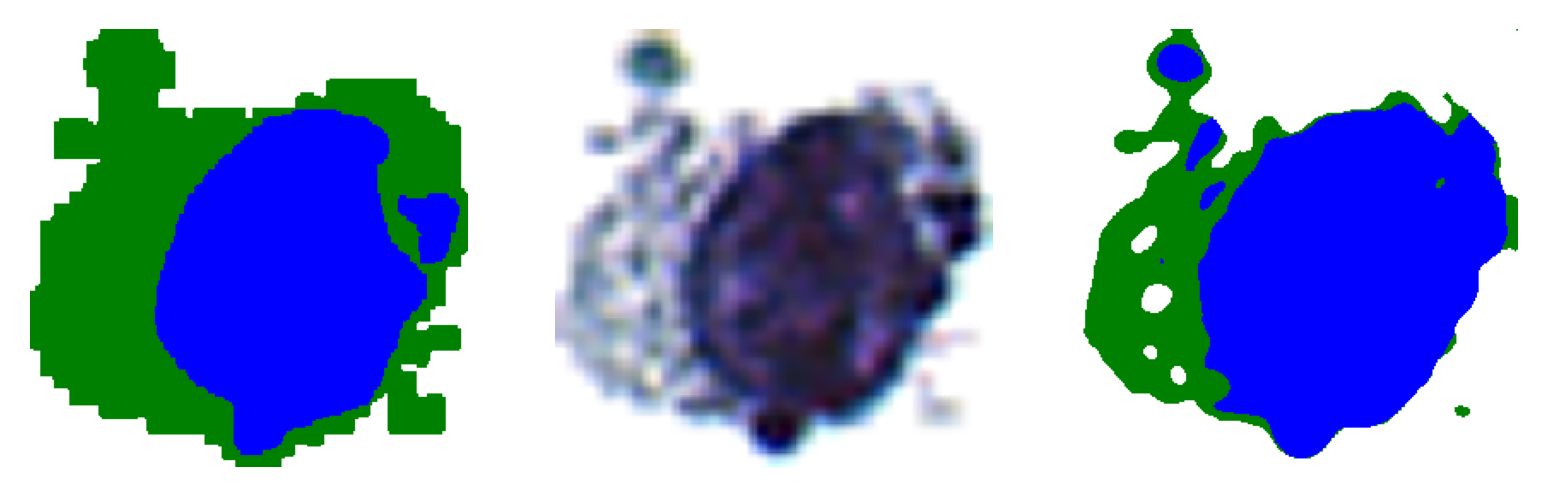

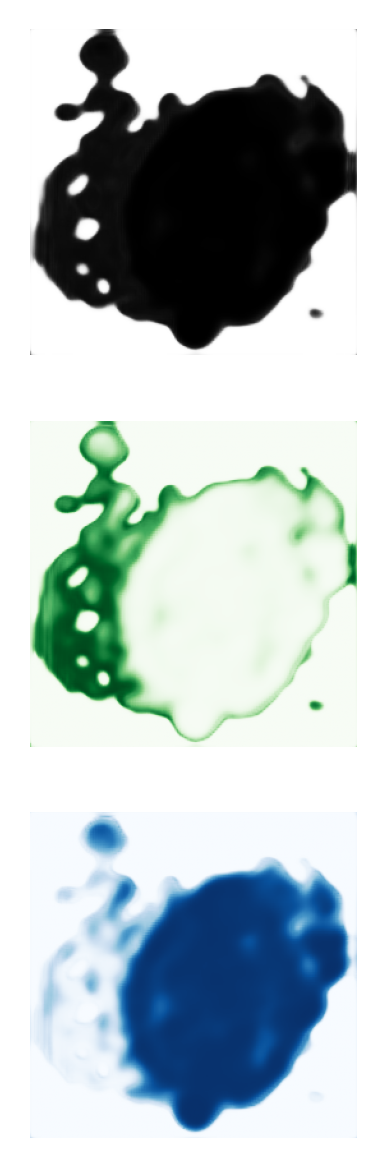

In [28]:
import matplotlib; matplotlib.rcParams['figure.dpi']=300
import matplotlib.pyplot as plt

idx=22
plt.figure()
plt.subplot(131)
plt.imshow(Y_val[idx], cmap=plt.matplotlib.colors.ListedColormap(['white', 'green', 'blue']))
plt.axis("off")
plt.subplot(132)
plt.imshow((X_val[idx]).permute((1,2,0)).numpy().astype(int))
plt.axis("off")
plt.subplot(133)
plt.imshow(y_val_pred_lbls[idx], cmap=plt.matplotlib.colors.ListedColormap(['white', 'green', 'blue']))
plt.axis("off")
plt.figure()
plt.subplot(311)
plt.imshow(y_val_pred[idx][0], cmap="Greys_r")
plt.axis("off")
plt.subplot(312)
plt.imshow(y_val_pred[idx][1], cmap="Greens")
plt.axis("off")
plt.subplot(313)
plt.imshow(y_val_pred[idx][2], cmap="Blues")
plt.axis("off")

In [29]:
model

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

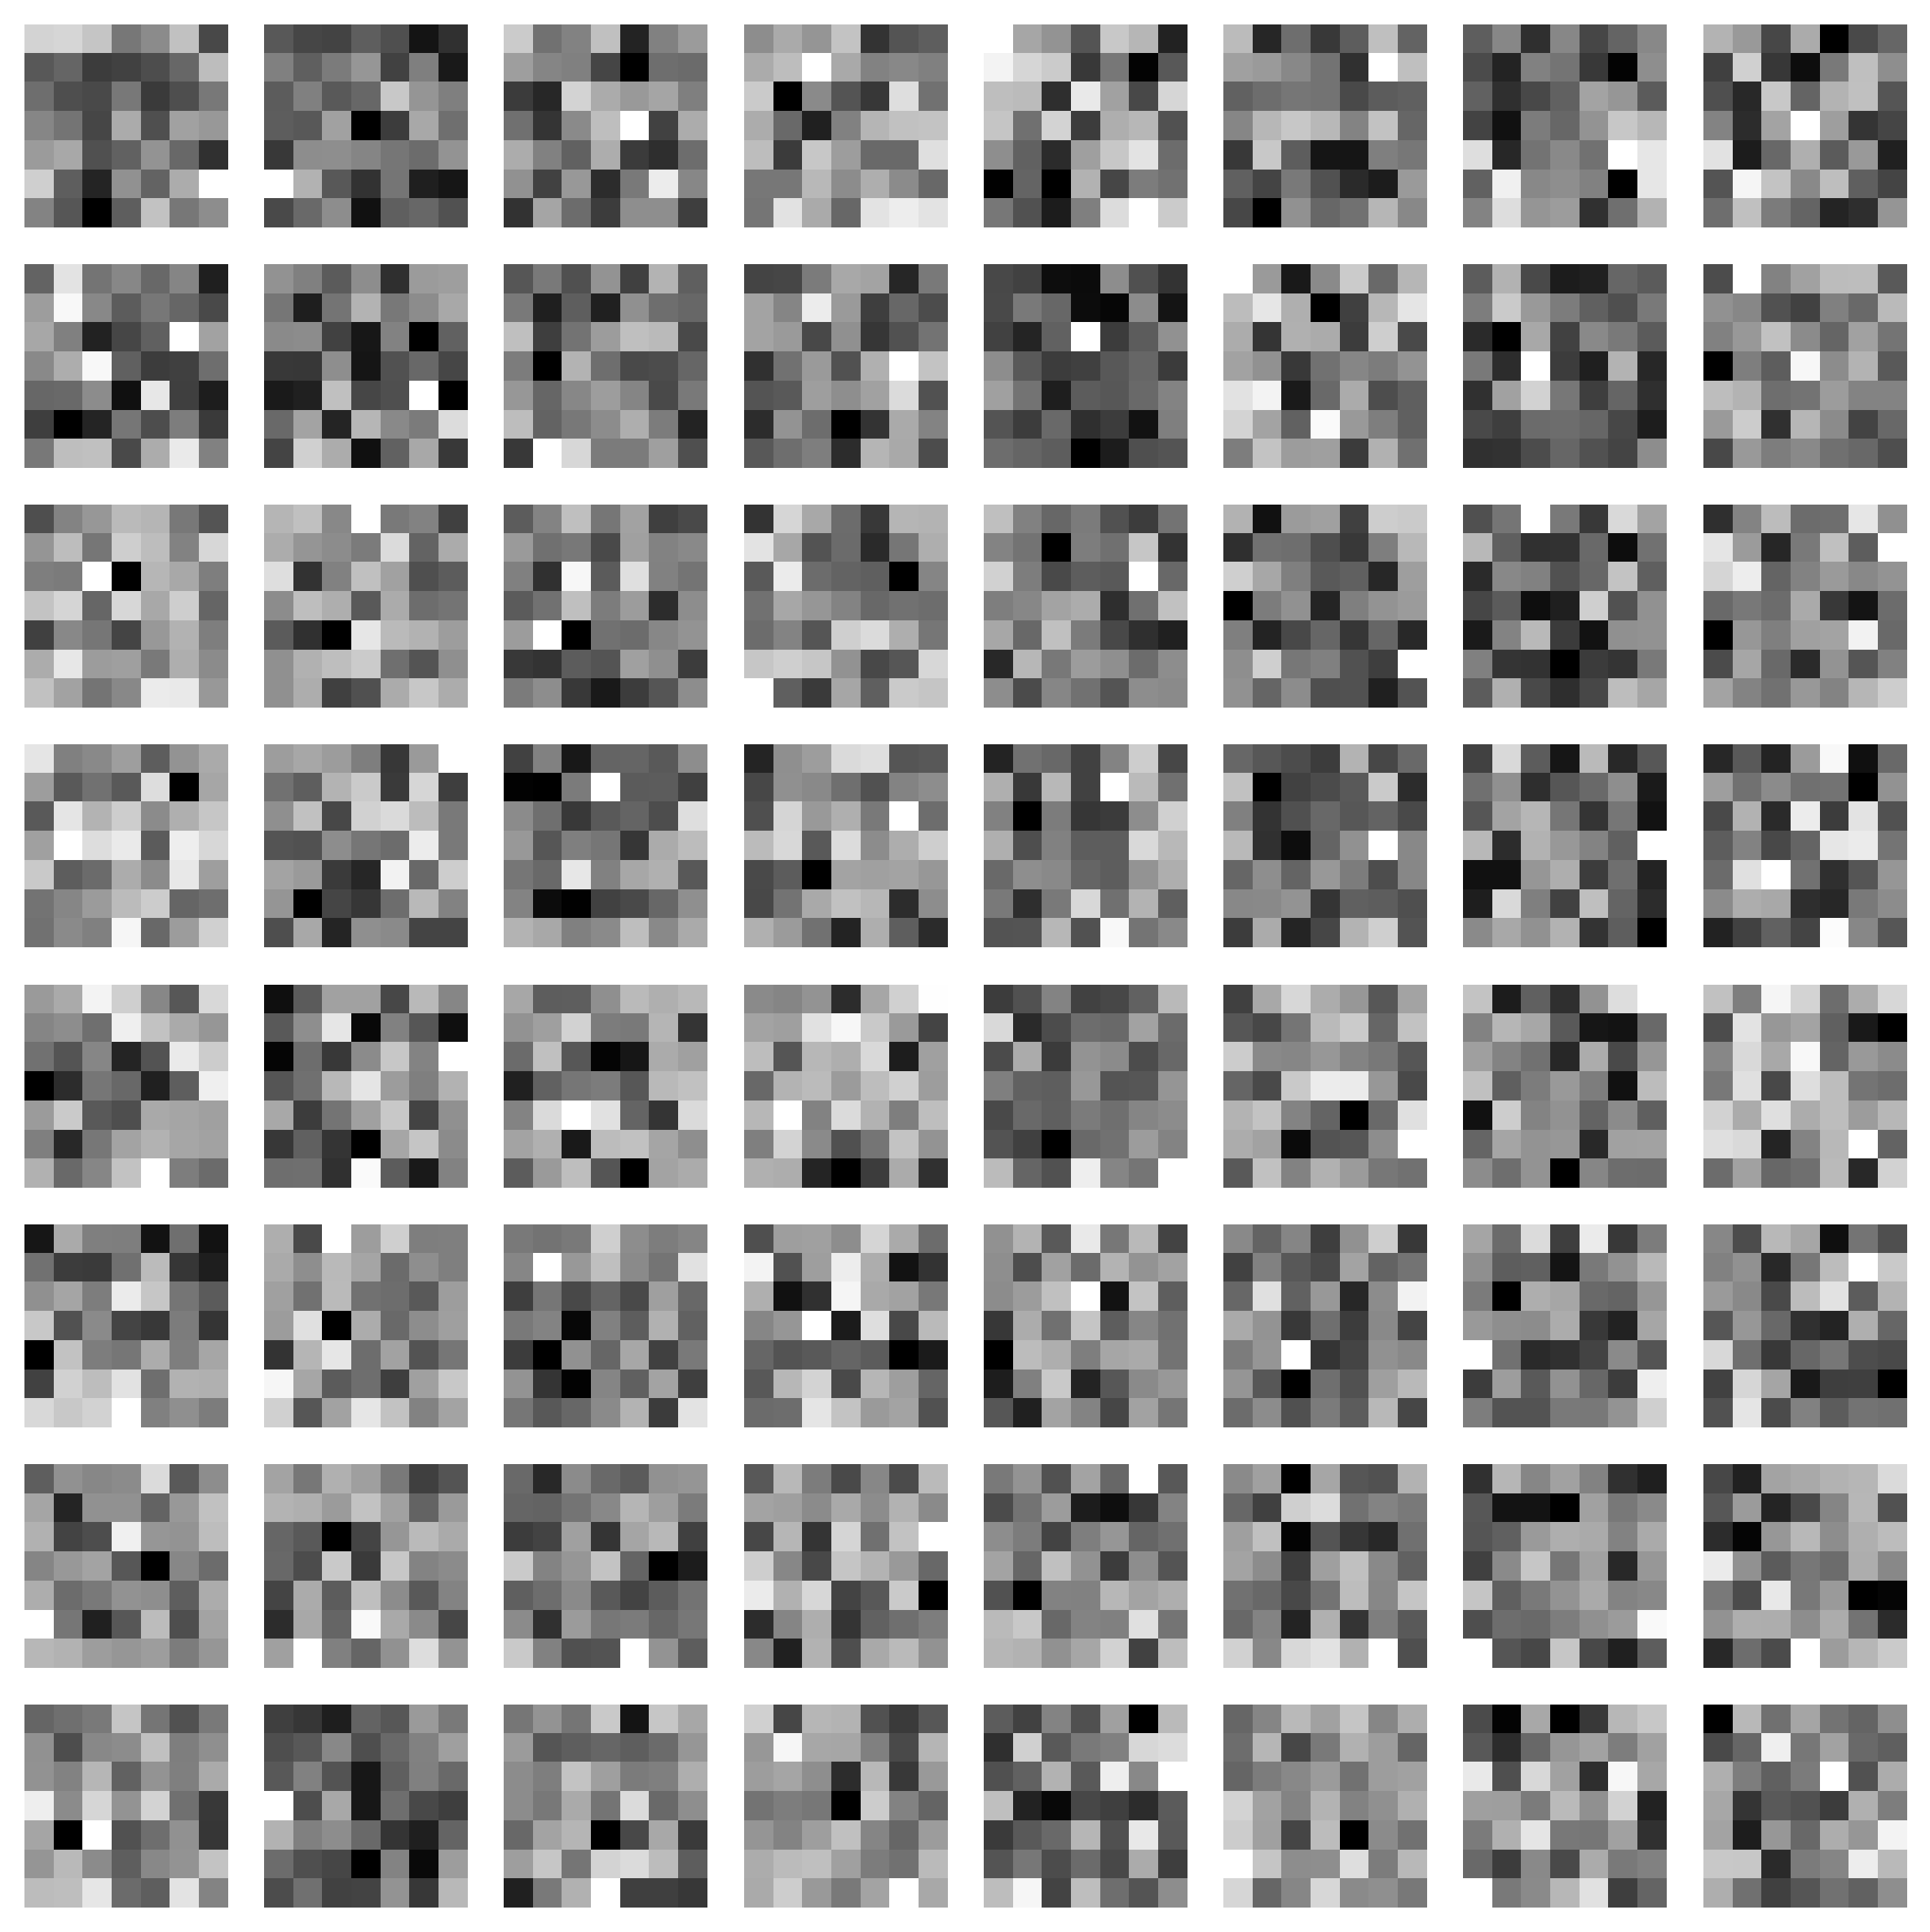

In [30]:
filters = model.encoder.conv1.weight
#.layer1[0].conv2.weight  # Shape: [out_channels, in_channels, height, width]
show_filters(filters)

In [31]:
dict(list(model.named_modules())).keys()

dict_keys(['', 'encoder', 'encoder.conv1', 'encoder.bn1', 'encoder.relu', 'encoder.maxpool', 'encoder.layer1', 'encoder.layer1.0', 'encoder.layer1.0.conv1', 'encoder.layer1.0.bn1', 'encoder.layer1.0.relu', 'encoder.layer1.0.conv2', 'encoder.layer1.0.bn2', 'encoder.layer1.1', 'encoder.layer1.1.conv1', 'encoder.layer1.1.bn1', 'encoder.layer1.1.relu', 'encoder.layer1.1.conv2', 'encoder.layer1.1.bn2', 'encoder.layer1.2', 'encoder.layer1.2.conv1', 'encoder.layer1.2.bn1', 'encoder.layer1.2.relu', 'encoder.layer1.2.conv2', 'encoder.layer1.2.bn2', 'encoder.layer2', 'encoder.layer2.0', 'encoder.layer2.0.conv1', 'encoder.layer2.0.bn1', 'encoder.layer2.0.relu', 'encoder.layer2.0.conv2', 'encoder.layer2.0.bn2', 'encoder.layer2.0.downsample', 'encoder.layer2.0.downsample.0', 'encoder.layer2.0.downsample.1', 'encoder.layer2.1', 'encoder.layer2.1.conv1', 'encoder.layer2.1.bn1', 'encoder.layer2.1.relu', 'encoder.layer2.1.conv2', 'encoder.layer2.1.bn2', 'encoder.layer2.2', 'encoder.layer2.2.conv1', 'en

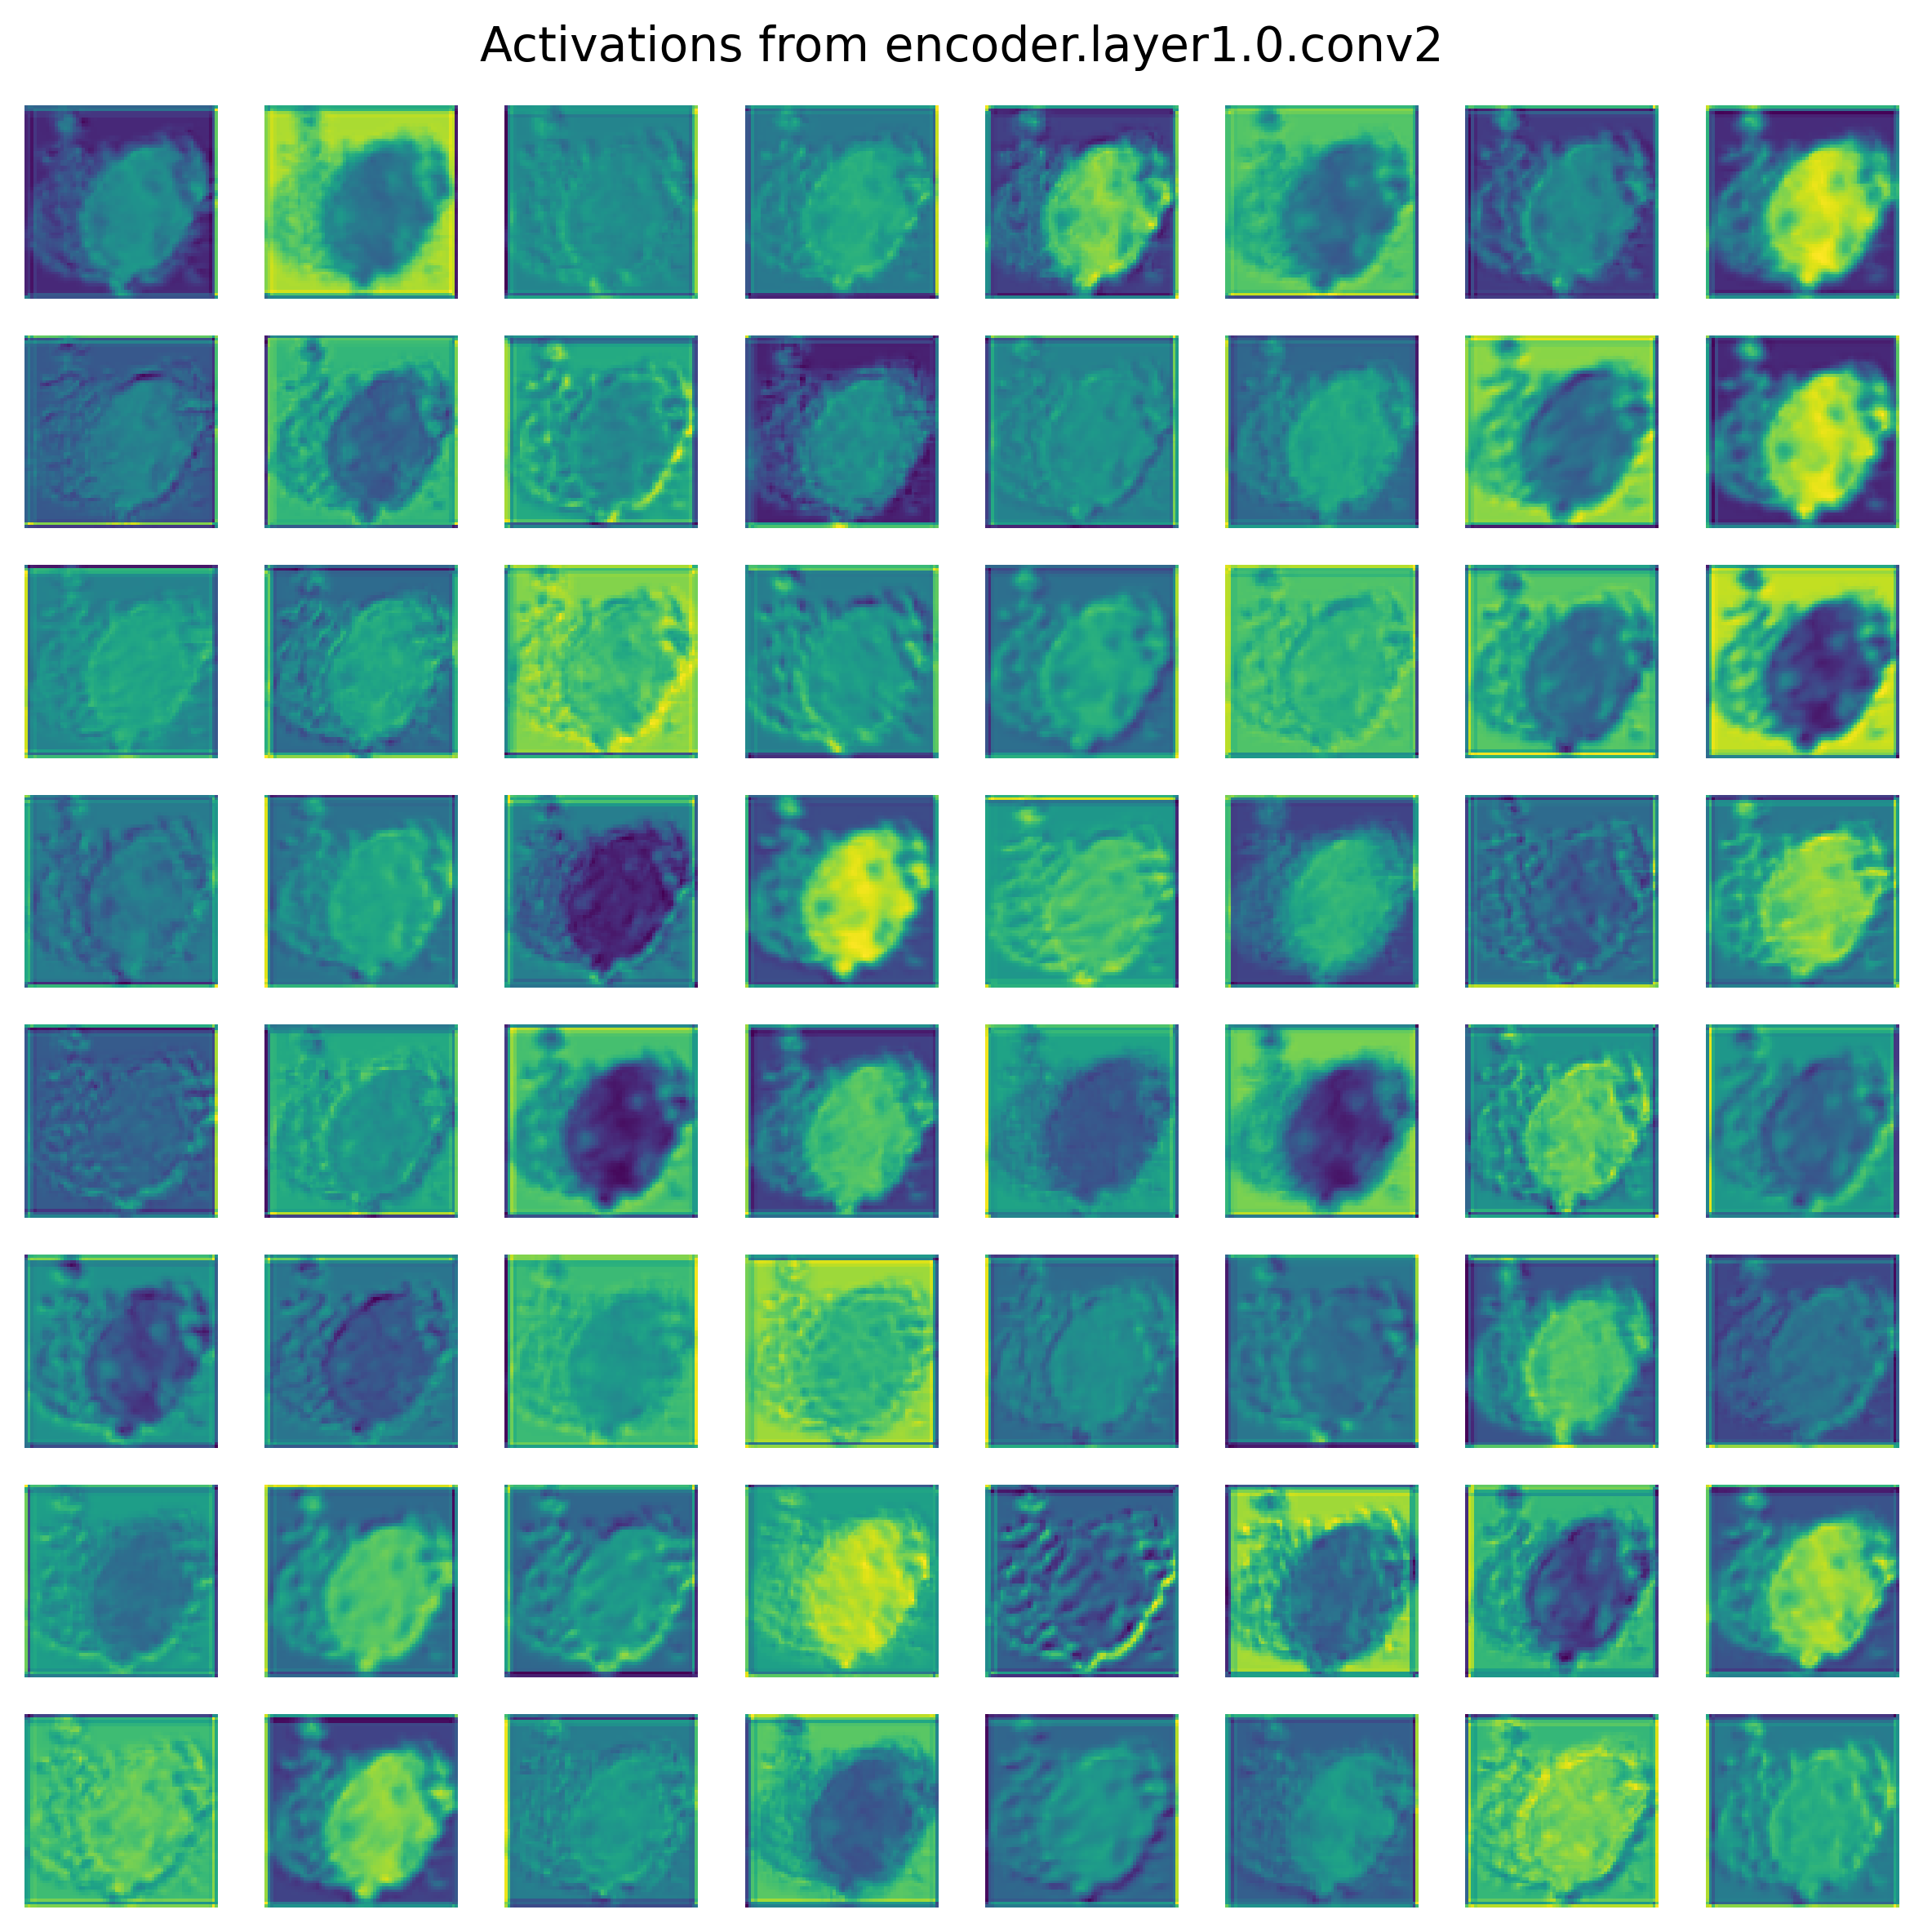

In [32]:
run_and_visualize_layer_activation(model,"encoder.layer1.0.conv2",X_val[idx].unsqueeze(0))

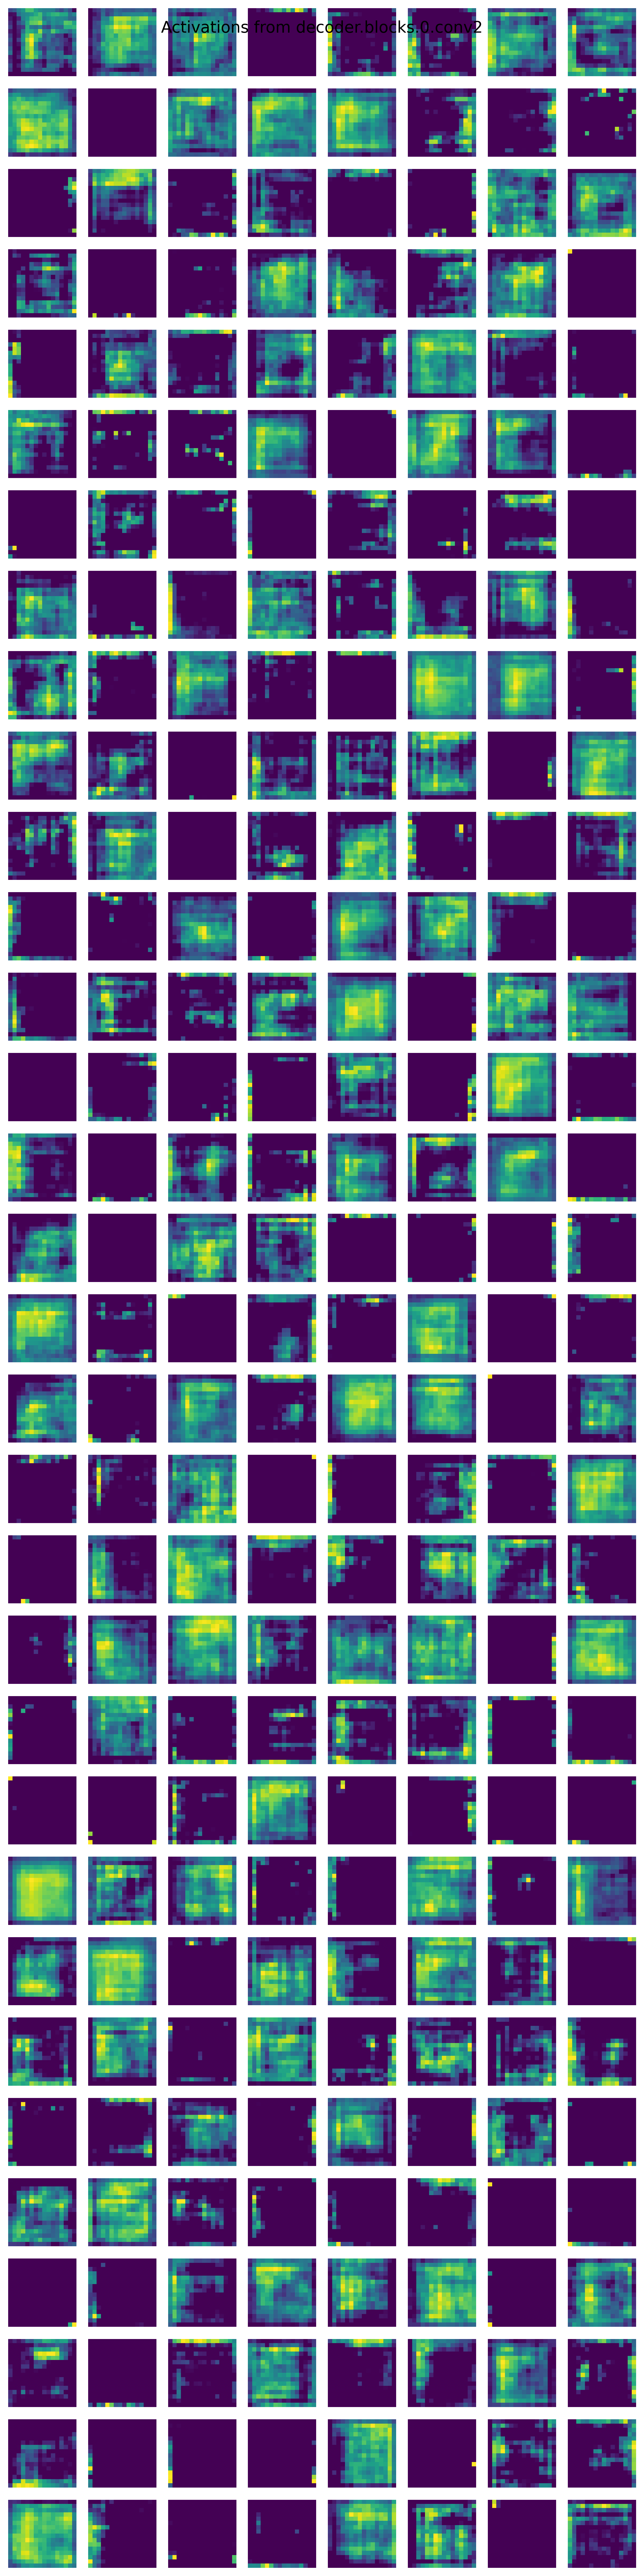

In [33]:
run_and_visualize_layer_activation(model,"decoder.blocks.0.conv2",X_val[idx].unsqueeze(0))

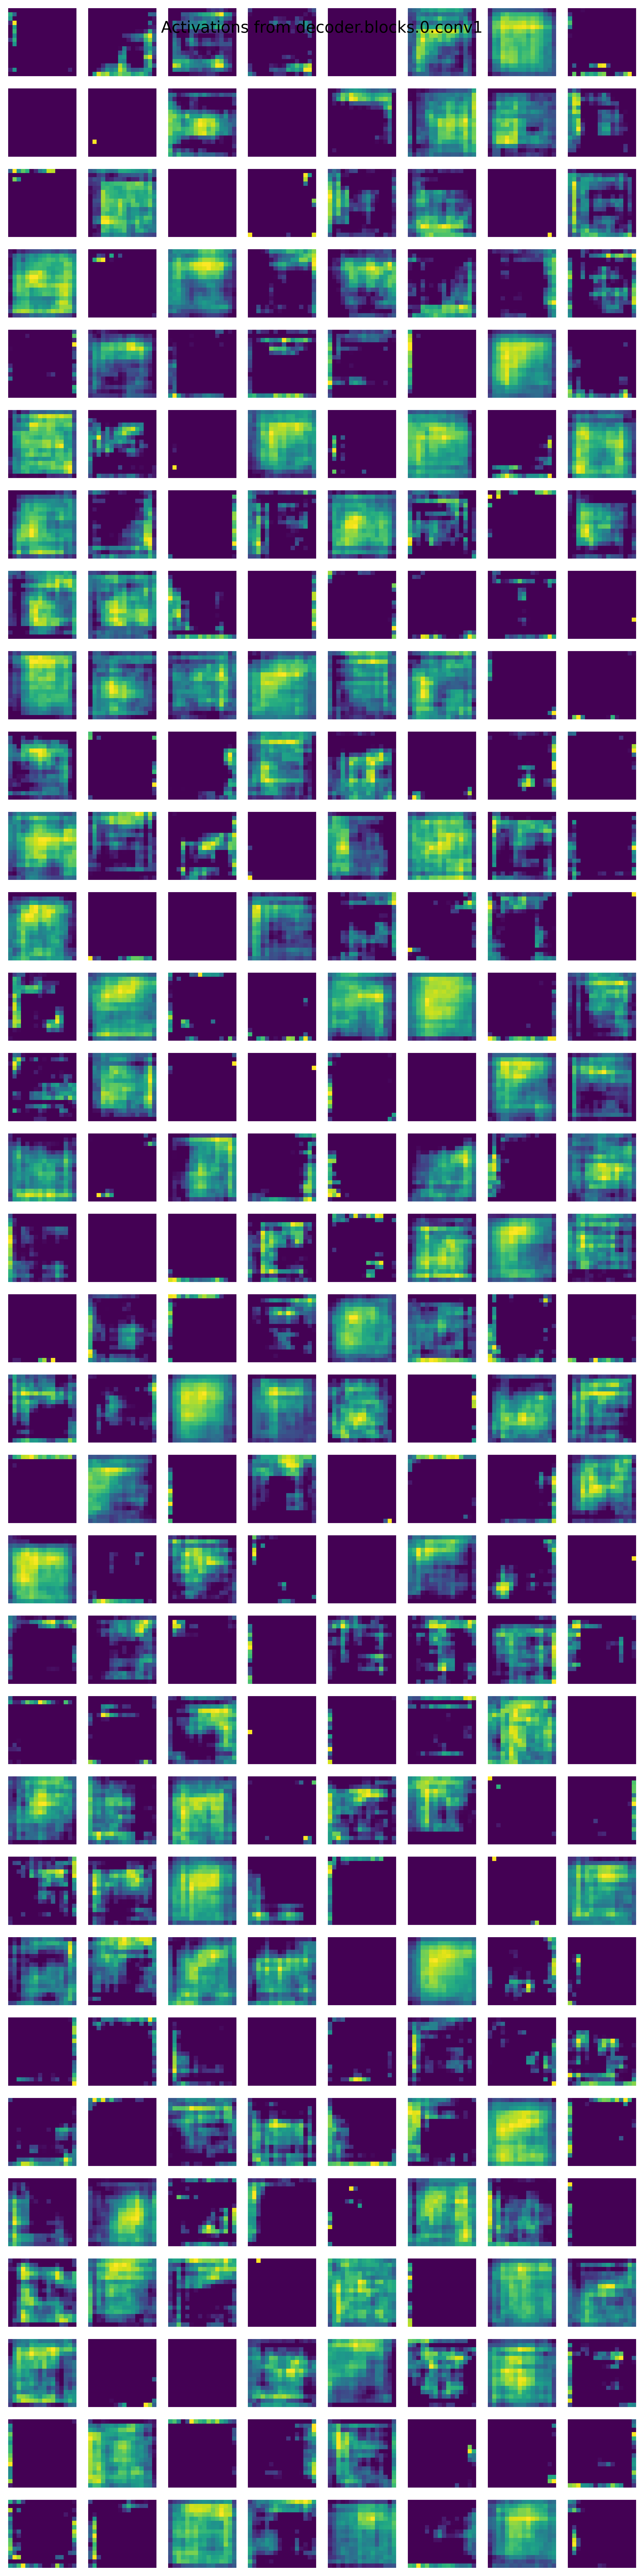

In [ ]:
run_and_visualize_layer_activation(model,"decoder.blocks.0.conv1",X_val[idx].unsqueeze(0))

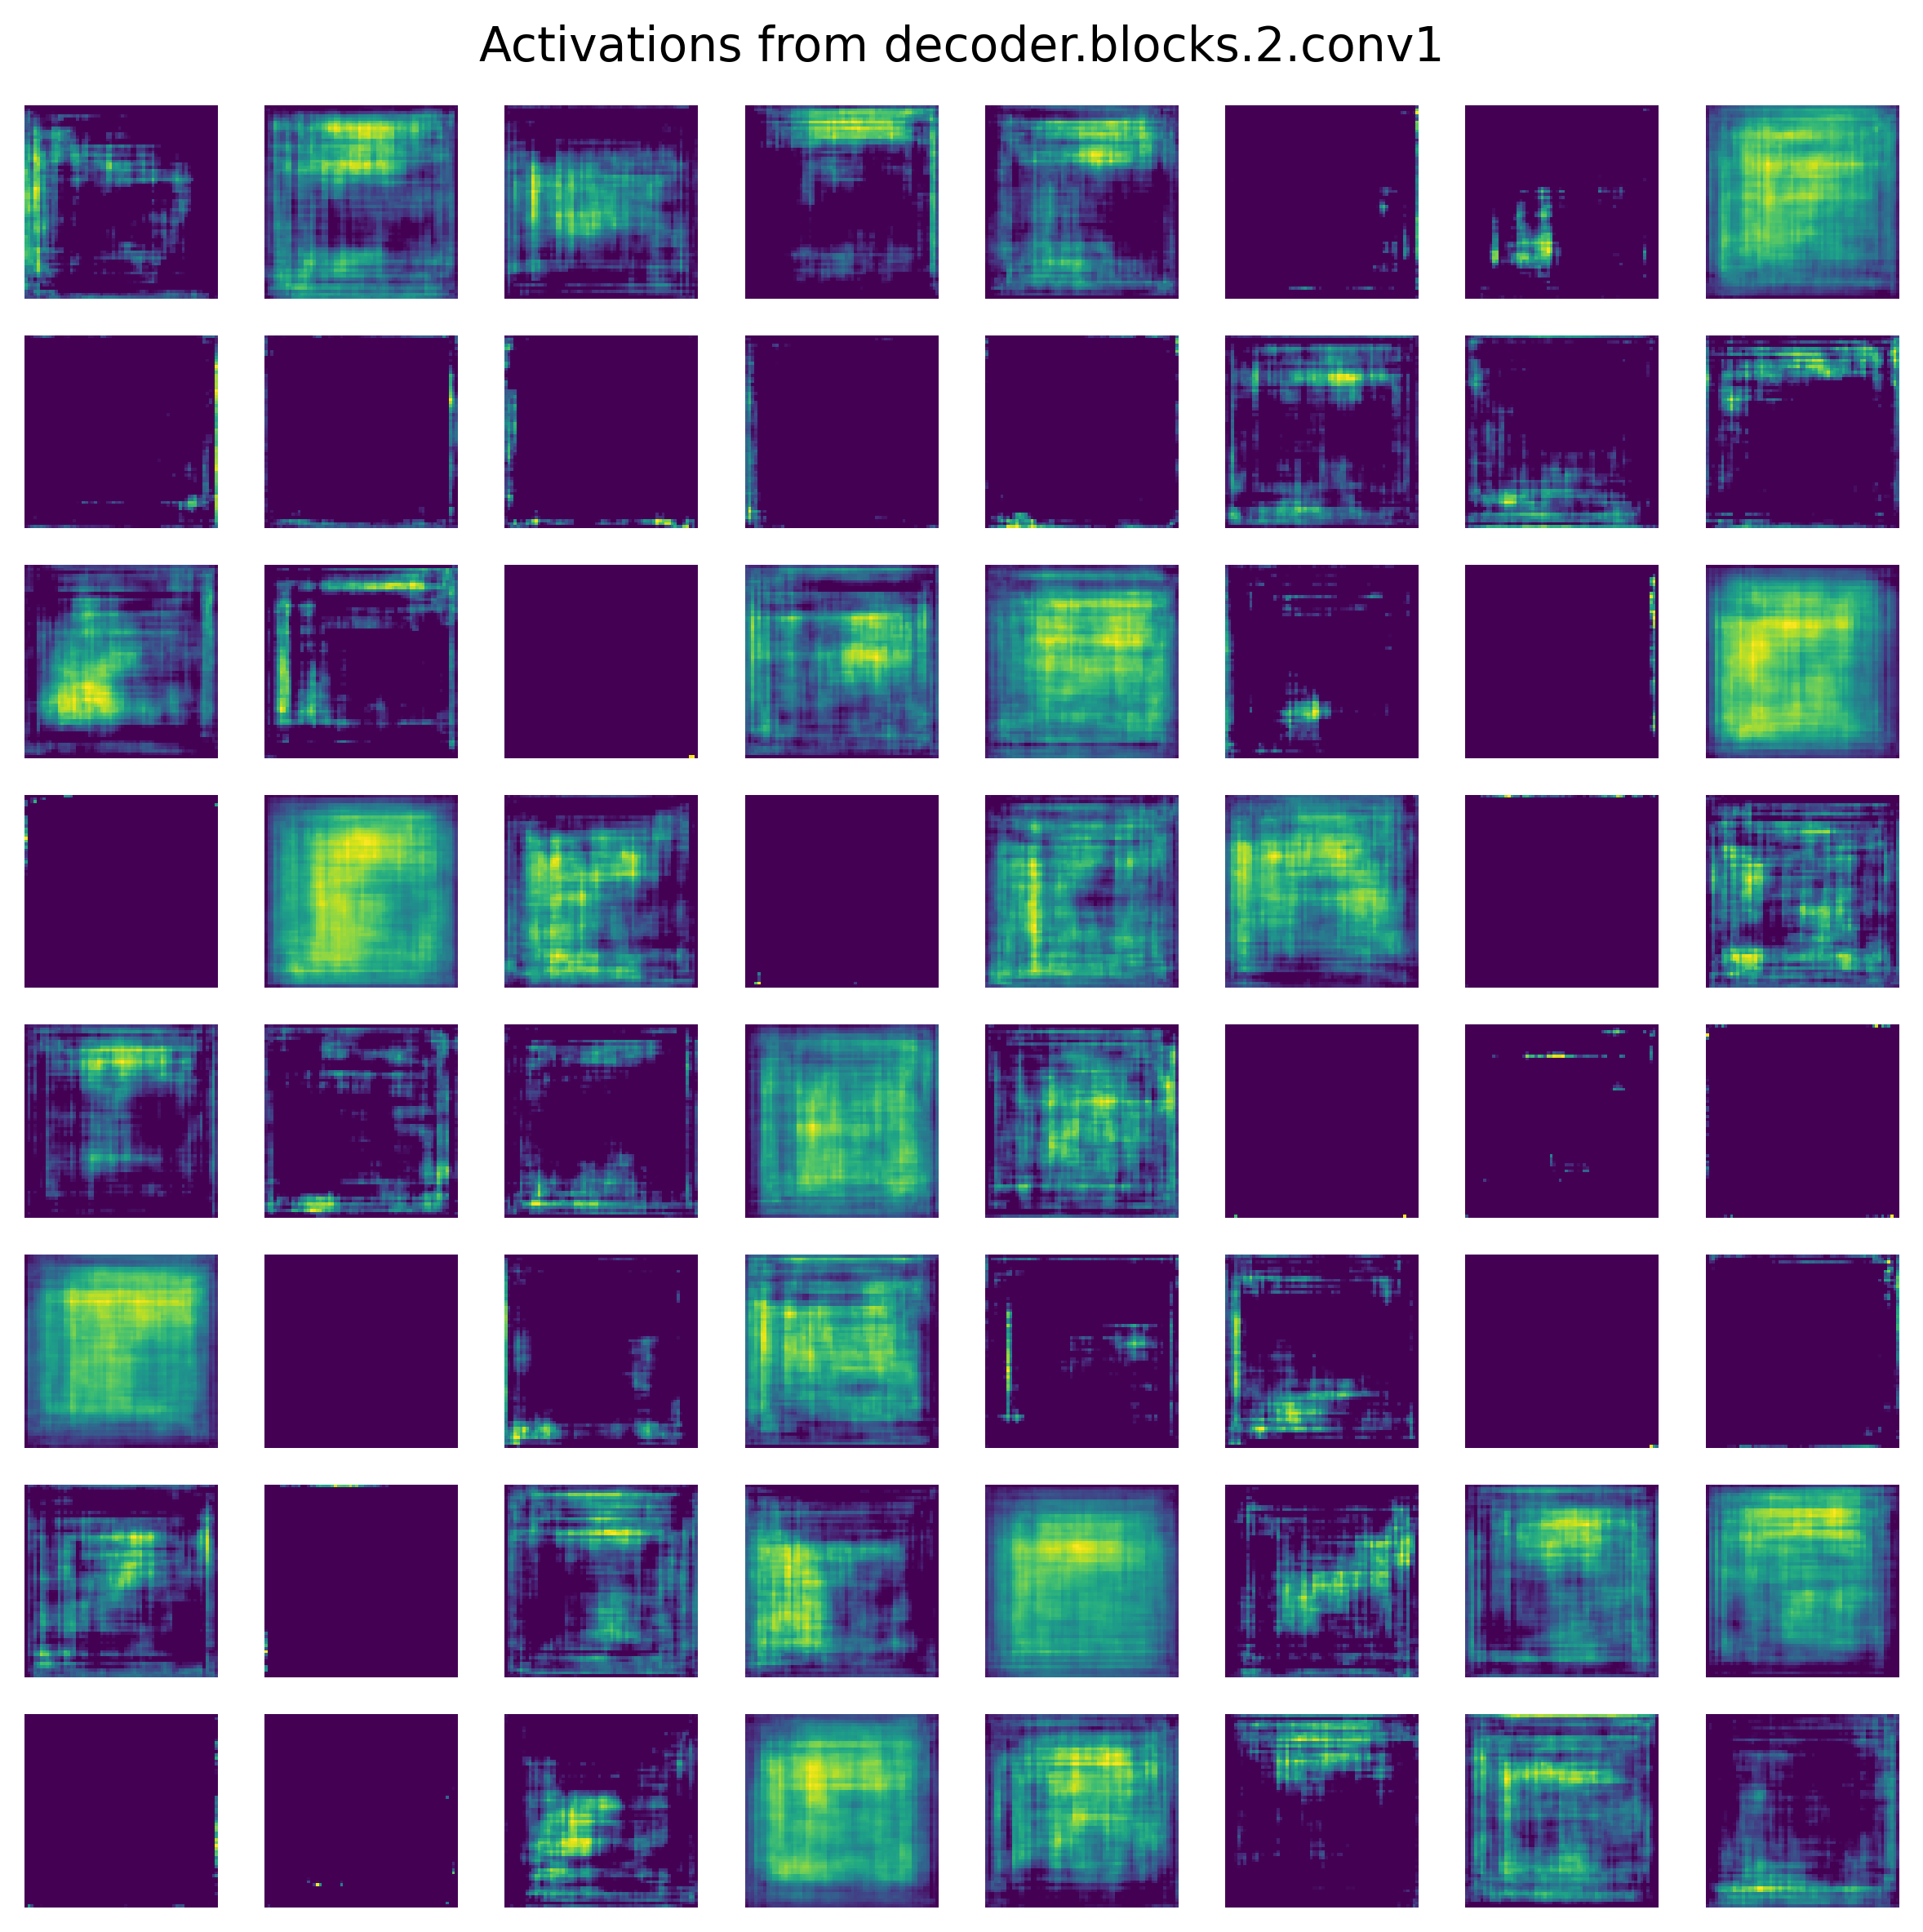

In [ ]:
run_and_visualize_layer_activation(model,"decoder.blocks.2.conv1",X_val[idx].unsqueeze(0))

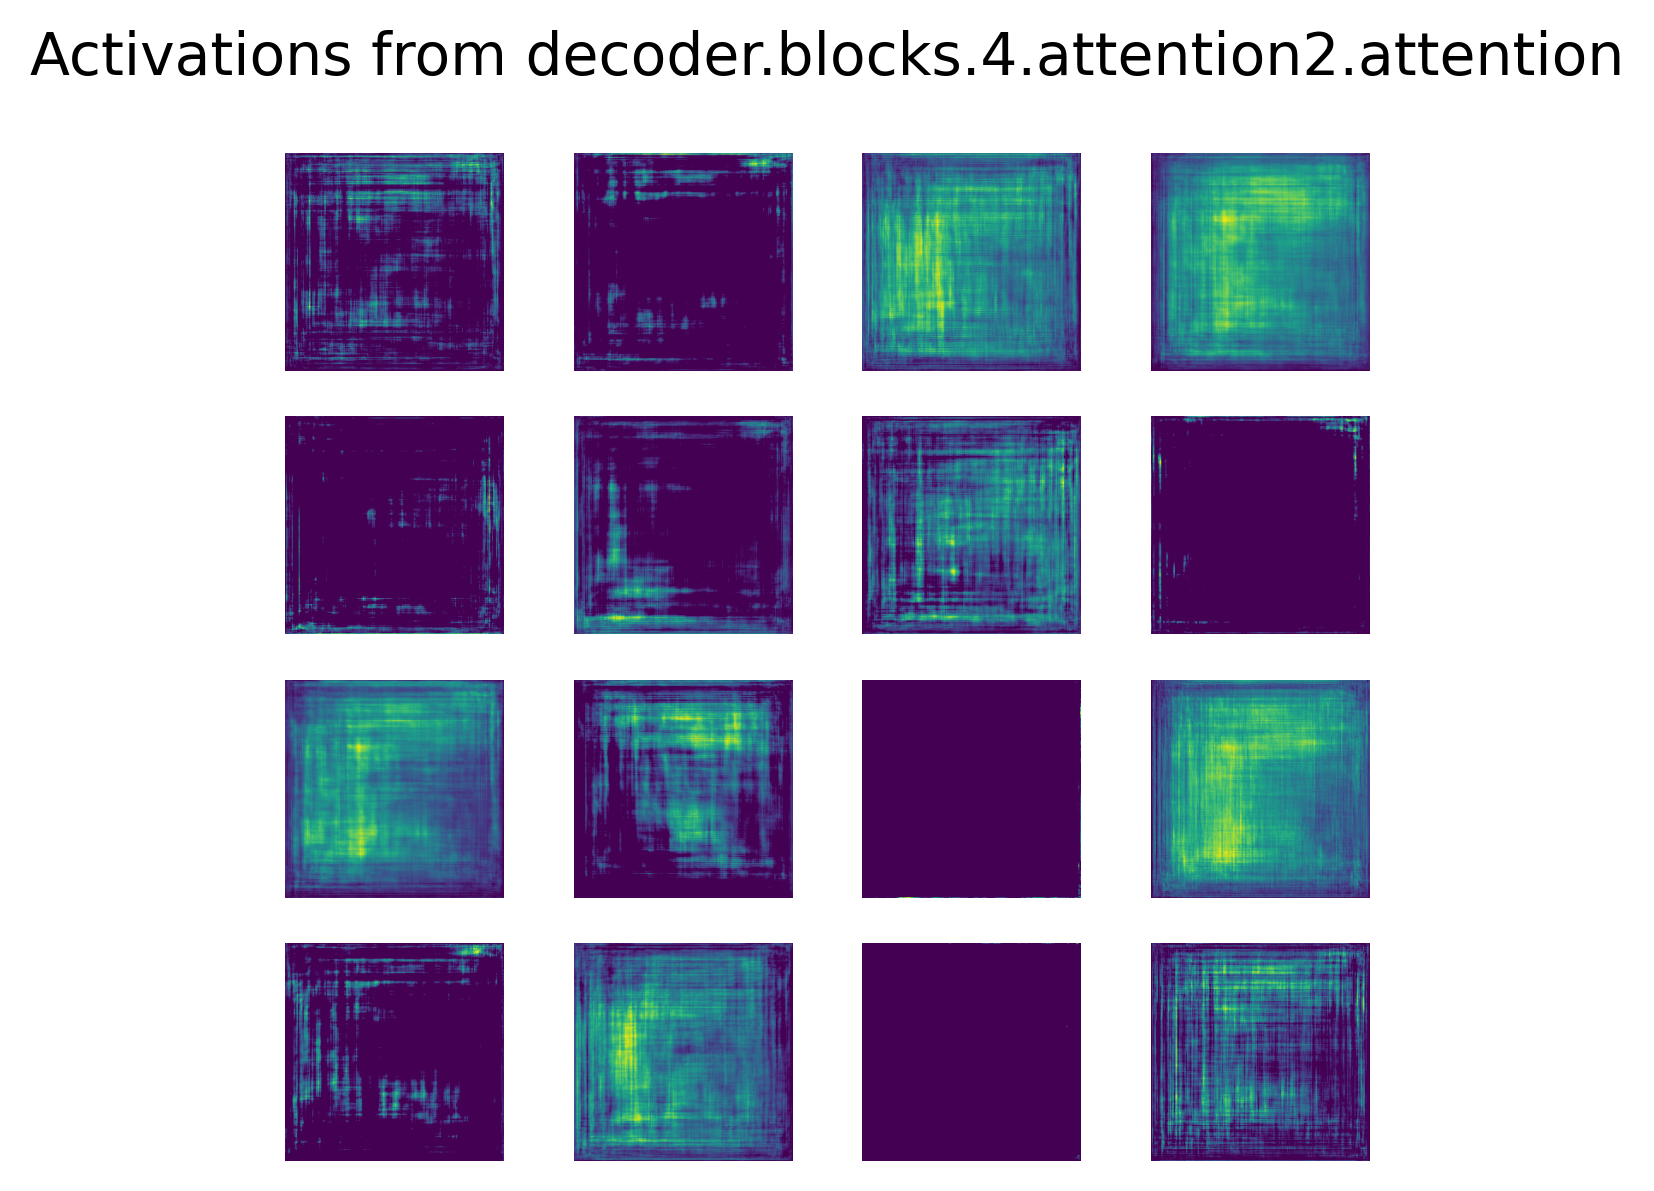

In [ ]:
run_and_visualize_layer_activation(model,"decoder.blocks.4.attention2.attention",X_val[idx].unsqueeze(0),n_cols=4)